# 20 Hz Cutoff (butter worth filter)

`torch_dtype` is deprecated! Use `dtype` instead!


Segment 1/32 — RMSE: 33.09 | MAPE: 1.64% | R²: 0.4693
Segment 2/32 — RMSE: 28.17 | MAPE: 1.17% | R²: 0.2280
Segment 3/32 — RMSE: 28.82 | MAPE: 0.90% | R²: 0.0413
Segment 4/32 — RMSE: 201.86 | MAPE: 6.19% | R²: 0.5577
Segment 5/32 — RMSE: 123.79 | MAPE: 3.62% | R²: 0.0644
Segment 6/32 — RMSE: 91.80 | MAPE: 2.19% | R²: 0.0081
Segment 7/32 — RMSE: 111.42 | MAPE: 1.87% | R²: 0.0220
Segment 8/32 — RMSE: 400.55 | MAPE: 4.87% | R²: 0.7954
Segment 9/32 — RMSE: 277.17 | MAPE: 2.84% | R²: 0.0132
Segment 10/32 — RMSE: 111.78 | MAPE: 1.28% | R²: 0.1145
Segment 11/32 — RMSE: 328.20 | MAPE: 3.54% | R²: 0.7150
Segment 12/32 — RMSE: 799.59 | MAPE: 11.23% | R²: 0.4364
Segment 13/32 — RMSE: 646.20 | MAPE: 10.40% | R²: 0.5864
Segment 14/32 — RMSE: 152.00 | MAPE: 2.36% | R²: 0.0239
Segment 15/32 — RMSE: 104.91 | MAPE: 1.52% | R²: 0.4225
Segment 16/32 — RMSE: 255.09 | MAPE: 3.57% | R²: 0.8865
Segment 17/32 — RMSE: 71.94 | MAPE: 0.66% | R²: 0.0078
Segment 18/32 — RMSE: 313.56 | MAPE: 2.82% | R²: 0.5762
Segm

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_37594/2796750860.py:145: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


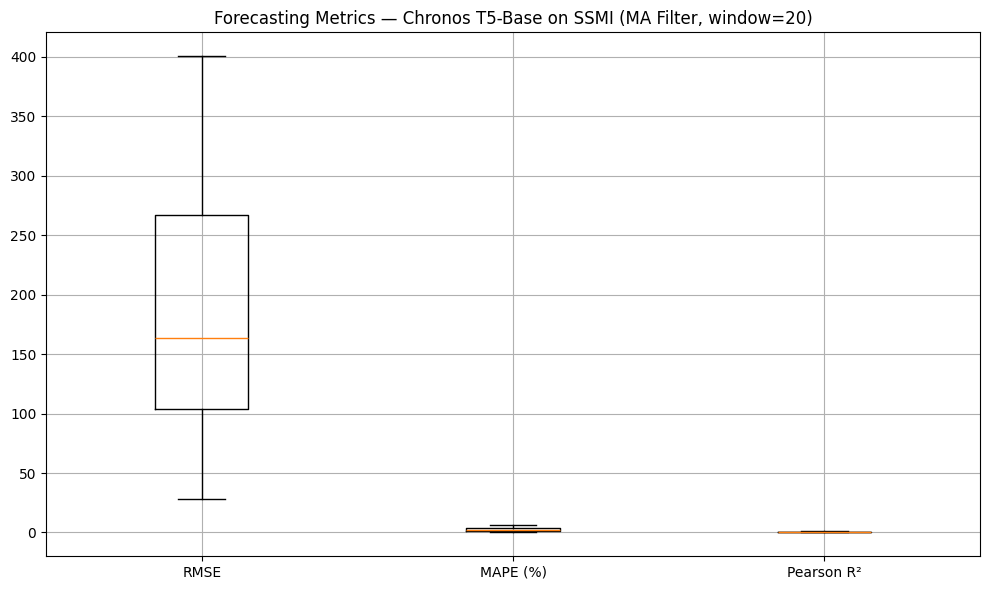

In [1]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

logging.basicConfig(
    filename='ChronosBase_SSMI_Filtered_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def moving_average_filter(y, window=20):
    """Smooth the signal using a moving average (low-frequency trend)."""
    low = np.convolve(y, np.ones(window)/window, mode='same')
    high = y - low  # residual / high-frequency component
    return low, high

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Apply filter
        # ========================
        filter_window = 20  # 20-day moving average (approx. 1 trading month)
        y_low, y_high = moving_average_filter(y, window=filter_window)
        logging.info(f"Moving average filter applied with window={filter_window}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 200
        forecast_horizon = 30
        step_size        = context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="cpu",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list    = []
        mape_list    = []
        pearson_list = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            # Split context into low and high components
            context_low  = torch.tensor(y_low[start_context:end_context].copy(),  dtype=torch.float32)
            context_high = torch.tensor(y_high[start_context:end_context].copy(), dtype=torch.float32)

            # True values (recombined)
            true_low      = y_low[end_context:end_context + forecast_horizon]
            true_high     = y_high[end_context:end_context + forecast_horizon]
            true_combined = true_low + true_high

            # Forecast low-frequency (trend)
            forecast_low = pipeline.predict(
                context_low,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Forecast high-frequency (residual)
            forecast_high = pipeline.predict(
                context_high,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            # Recombine predictions
            median_low    = np.median(forecast_low[0].numpy(),  axis=0)
            median_high   = np.median(forecast_high[0].numpy(), axis=0)
            combined_pred = median_low + median_high

            # Metrics
            rmse       = np.sqrt(mean_squared_error(true_combined, combined_pred))
            mape       = mean_absolute_percentage_error(true_combined, combined_pred) * 100
            pearson_r2 = pearsonr(true_combined, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R²={pearson_r2:.4f}")
            print(f"Segment {segment+1}/{num_segments} — RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {pearson_r2:.4f}")

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed("ChronosBase_SSMI_Filtered_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            pearson_coefficients=np.array(pearson_list),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            filter_window=filter_window,
                            num_segments=num_segments)
        logging.info("Results saved to ChronosBase_SSMI_Filtered_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        print("\n--- Median Metrics for Chronos T5-Base on SSMI (Filtered) ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R²: {np.median(pearson_list):.4f}")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R²": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(f"Forecasting Metrics — Chronos T5-Base on SSMI (MA Filter, window={filter_window})")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_Filtered_Metrics.log for details.")
        try:
            np.savez_compressed("partial_ChronosBase_SSMI_Filtered_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()

In [3]:
import numpy as np

data = np.load("ChronosBase_SSMI_Filtered_Metrics.npz")

print("--- Median Metrics for Chronos T5-Base on SSMI (Filtered) ---")
print(f"Median RMSE:       {np.median(data['rmse']):.4f}")
print(f"Median MAPE:       {np.median(data['mape']):.4f}%")
print(f"Median Pearson R²: {np.median(data['pearson_coefficients']):.4f}")

--- Median Metrics for Chronos T5-Base on SSMI (Filtered) ---
Median RMSE:       163.3692
Median MAPE:       2.1770%
Median Pearson R²: 0.2640


# Hodrick–Prescott filter

Segment 1/32 — RMSE: 36.18 | MAPE: 1.86% | R²: 0.3697 | Dir Acc: 66.7%
Segment 2/32 — RMSE: 27.59 | MAPE: 1.13% | R²: 0.2422 | Dir Acc: 46.7%
Segment 3/32 — RMSE: 38.12 | MAPE: 1.23% | R²: 0.1538 | Dir Acc: 56.7%
Segment 4/32 — RMSE: 75.87 | MAPE: 2.57% | R²: 0.1406 | Dir Acc: 56.7%
Segment 5/32 — RMSE: 124.40 | MAPE: 3.77% | R²: 0.7359 | Dir Acc: 70.0%
Segment 6/32 — RMSE: 58.16 | MAPE: 1.38% | R²: 0.0190 | Dir Acc: 46.7%
Segment 7/32 — RMSE: 112.60 | MAPE: 1.90% | R²: 0.0100 | Dir Acc: 50.0%
Segment 8/32 — RMSE: 80.02 | MAPE: 0.93% | R²: 0.9378 | Dir Acc: 66.7%
Segment 9/32 — RMSE: 300.48 | MAPE: 3.20% | R²: 0.0531 | Dir Acc: 50.0%
Segment 10/32 — RMSE: 99.83 | MAPE: 0.99% | R²: 0.0467 | Dir Acc: 43.3%
Segment 11/32 — RMSE: 160.90 | MAPE: 1.82% | R²: 0.3673 | Dir Acc: 50.0%
Segment 12/32 — RMSE: 383.38 | MAPE: 5.09% | R²: 0.4423 | Dir Acc: 66.7%
Segment 13/32 — RMSE: 255.92 | MAPE: 4.19% | R²: 0.0093 | Dir Acc: 43.3%
Segment 14/32 — RMSE: 86.53 | MAPE: 1.40% | R²: 0.4528 | Dir Acc: 4

/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/ipykernel_37594/3659068139.py:160: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


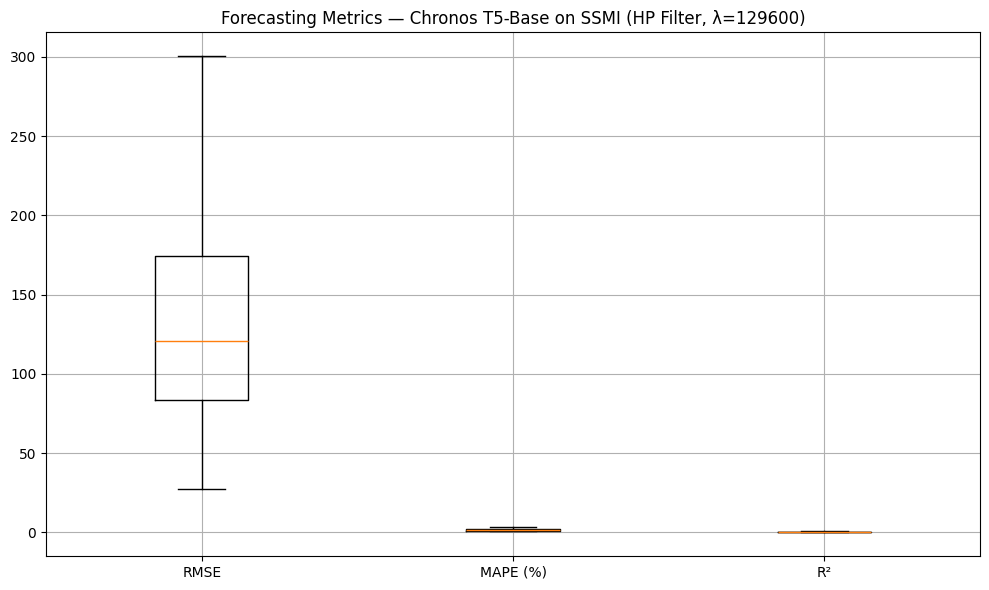

In [11]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.filters.hp_filter import hpfilter

logging.basicConfig(
    filename='ChronosBase_SSMI_HP_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Apply HP filter
        # ========================
        lamb = 129600
        cycle, trend = hpfilter(y, lamb=lamb)
        y_low  = trend
        y_high = cycle
        logging.info(f"HP filter applied with lambda={lamb}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 200
        forecast_horizon = 30
        step_size        = context_window + forecast_horizon
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load Chronos
        # ========================
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-base",
            device_map="cpu",
            torch_dtype=torch.float32,
        )
        logging.info("Chronos T5-Base loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        r2_list          = []
        directional_hits = []  # 1 if direction correct (up or down), 0 otherwise

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            context_low  = torch.tensor(y_low[start_context:end_context].copy(),  dtype=torch.float32)
            context_high = torch.tensor(y_high[start_context:end_context].copy(), dtype=torch.float32)

            true_low      = y_low[end_context:end_context + forecast_horizon]
            true_high     = y_high[end_context:end_context + forecast_horizon]
            true_combined = true_low + true_high

            forecast_low = pipeline.predict(
                context_low,
                prediction_length=forecast_horizon,
                num_samples=20,
            )
            forecast_high = pipeline.predict(
                context_high,
                prediction_length=forecast_horizon,
                num_samples=20,
            )

            median_low    = np.median(forecast_low[0].numpy(),  axis=0)
            median_high   = np.median(forecast_high[0].numpy(), axis=0)
            combined_pred = median_low + median_high

            # ========================
            # Directional accuracy
            # (correct up AND correct down)
            # ========================
            prev_day_price = y[end_context - 1]

            # Previous day anchor for actual and forecast
            actual_prev = np.concatenate([[prev_day_price], true_combined[:-1]])
            pred_prev   = np.concatenate([[prev_day_price], combined_pred[:-1]])

            actual_direction = np.sign(true_combined - actual_prev)  # +1 up, -1 down, 0 flat
            pred_direction   = np.sign(combined_pred  - pred_prev)   # +1 up, -1 down, 0 flat

            # 1 point if direction matches (both up or both down)
            hits = (actual_direction == pred_direction).astype(int)
            directional_hits.extend(hits.tolist())

            # Standard metrics
            rmse = np.sqrt(mean_squared_error(true_combined, combined_pred))
            mape = mean_absolute_percentage_error(true_combined, combined_pred) * 100
            r2 = pearsonr(true_combined, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            r2_list.append(r2)

            segment_dir_acc = hits.mean() * 100
            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, R²={r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} — RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed("ChronosBase_SSMI_HP_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            r2=np.array(r2_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            lamb=lamb,
                            num_segments=num_segments)
        logging.info("Results saved to ChronosBase_SSMI_HP_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Chronos T5-Base on SSMI (HP Filter) ---")
        print(f"Median RMSE:          {np.median(rmse_list):.4f}")
        print(f"Median MAPE:          {np.median(mape_list):.4f}%")
        print(f"Median R²:            {np.median(r2_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":     rmse_list,
            "MAPE (%)": mape_list,
            "R²":       r2_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(f"Forecasting Metrics — Chronos T5-Base on SSMI (HP Filter, λ={lamb})")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check ChronosBase_SSMI_HP_Metrics.log for details.")
        try:
            np.savez_compressed("partial_ChronosBase_SSMI_HP_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                r2=np.array(r2_list) if 'r2_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()